In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
# import loglike
# import modeselector
# import parismc
# import gc
import pickle
import dynesty
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

In [2]:
print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.


In [3]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [4]:
print('Generating data signal...')
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
print('Done generating data signal.')

Generating data signal...
Done generating data signal.


In [5]:
print('Setting up GWFuncs...')
gwf = GWfuncs.GravWaveAnalysis(T, dt)
print('Done setting up GWFuncs.')

Setting up GWFuncs...
Done setting up GWFuncs.


In [6]:
data_f = gwf.freq_wave(data)
gwf.SNR(data_f)

array(107.43944631)

# Loglike, prior

In [7]:
def loglike(params):
    logm1, logm2, a, p0, e0, dist, cosqS, phiS, Phi_phi0, Phi_r0 = params
    m1 = 10**logm1
    m2 = 10**logm2
    qS = np.arccos(cosqS)
    phiK = phiS + np.pi/3

    htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
            
    res = data - htemp
    res_f = gwf.freq_wave(res)
    inner_res = gwf.inner(res_f, res_f)
    log_like = -0.5 * inner_res.get()
    return log_like

In [8]:
def prior_transform(utheta):
    ulogm1, ulogm2, ua, up0, ue0, udist, ucosqS, uphiS, uPhi_phi0, uPhi_r0 = utheta

    # 3 sigma ranges
    logm1_range = (5.9998955889e+00, 6.0001044111e+00)
    logm2_range = (1.4770586003e+00, 1.4771839092e+00)
    a_range = (6.9991943608e-01, 7.0008056392e-01)
    p0_range = (7.4995568044e+00, 7.5004431956e+00)
    e0_range = (3.9997901137e-01, 4.0002098863e-01)
    dist_range = (1.9727323083e+00, 2.0272676917e+00)
    cosqS_range = (8.6479203952e-01, 8.9037308426e-01)
    phiS_range = (9.7750458220e-01, 1.0224954178e+00)
    Phi_phi0_range = (3.8232596200e-01, 4.1767403800e-01)
    Phi_r0_range = (4.9151222865e-01, 5.0848777135e-01)

    # All uniform
    logm1 = (logm1_range[1] - logm1_range[0]) * ulogm1 + logm1_range[0]
    logm2 = (logm2_range[1] - logm2_range[0]) * ulogm2 + logm2_range[0]
    a = (a_range[1] - a_range[0]) * ua + a_range[0]
    p0 = (p0_range[1] - p0_range[0]) * up0 + p0_range[0]
    e0 = (e0_range[1] - e0_range[0]) * ue0 + e0_range[0]
    dist = (dist_range[1] - dist_range[0]) * udist + dist_range[0]
    cosqS = (cosqS_range[1] - cosqS_range[0]) * ucosqS + cosqS_range[0]
    phiS = (phiS_range[1] - phiS_range[0]) * uphiS + phiS_range[0]
    Phi_phi0 = (Phi_phi0_range[1] - Phi_phi0_range[0]) * uPhi_phi0 + Phi_phi0_range[0]
    Phi_r0 = (Phi_r0_range[1] - Phi_r0_range[0]) * uPhi_r0 + Phi_r0_range[0]

    return logm1, logm2, a, p0, e0, dist, cosqS, phiS, Phi_phi0, Phi_r0

In [ ]:
print('Done setting up loglike and prior_transform functions.')
print('Starting nested sampling...')
rstate = np.random.default_rng(7)
with dynesty.pool.Pool(16, loglike, prior_transform) as pool:
    dsampler = dynesty.DynamicNestedSampler(
        loglike,  
        prior_transform,
        ndim=10,
        bound='multi',
        sample='rwalk',
        rstate=rstate,
        nlive=500
    )
    dsampler.run_nested(checkpoint_file='ns_likelihoodtest.save')

print('Done nested sampling.')
print('Saving results to pickle...')
results = dsampler.results
with open('ns_likelihoodtest.pkl', 'wb') as f:
    pickle.dump(results, f)

# Analyze Results

In [7]:
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

In [8]:
with open('ns_likelihoodtest_wide.pkl', 'rb') as f:
    dres = pickle.load(f) # deserialize using load()

In [9]:
dres.summary()

Summary
niter: 25134
ncall: 629766
eff(%):  3.579
logz: -30.304 +/-  0.152


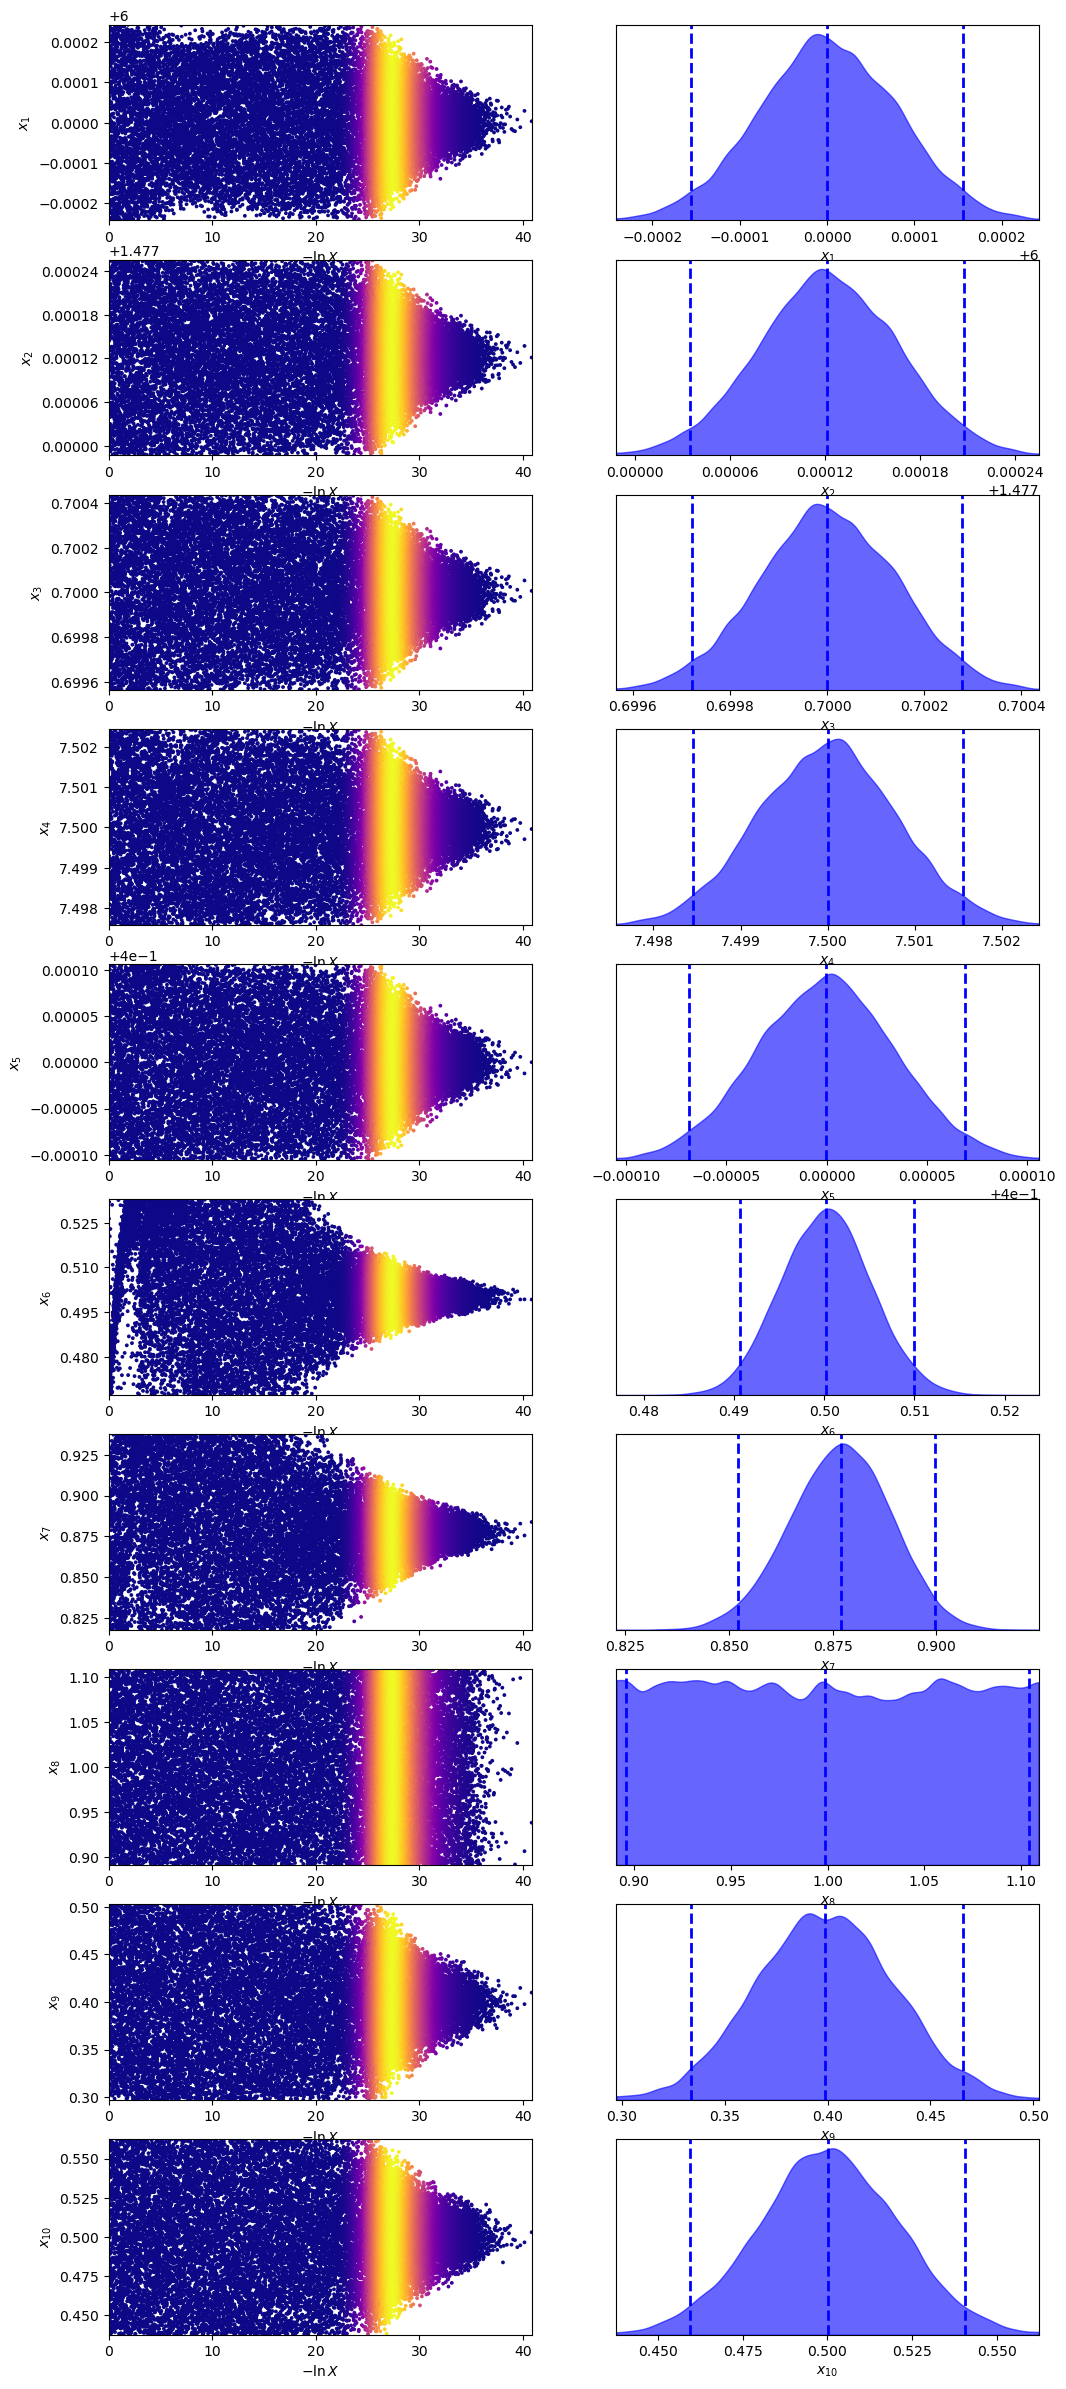

In [10]:
from dynesty import plotting as dyplot
import matplotlib.pyplot as plt
fig, axes = dyplot.traceplot(dres)
plt.show()

In [11]:
from dynesty import utils as dyfunc

samples, weights = dres.samples, dres.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
ndim = len(mean)
imp_weights = dres.importance_weights()

In [12]:
labels = ['logm1', 'logm2', 'a', 'p0', 'e0', 'dist', 'cosqS', 'phiS', 'Phi_phi0', 'Phi_r0']

In [16]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, Phi_phi0, Phi_r0]

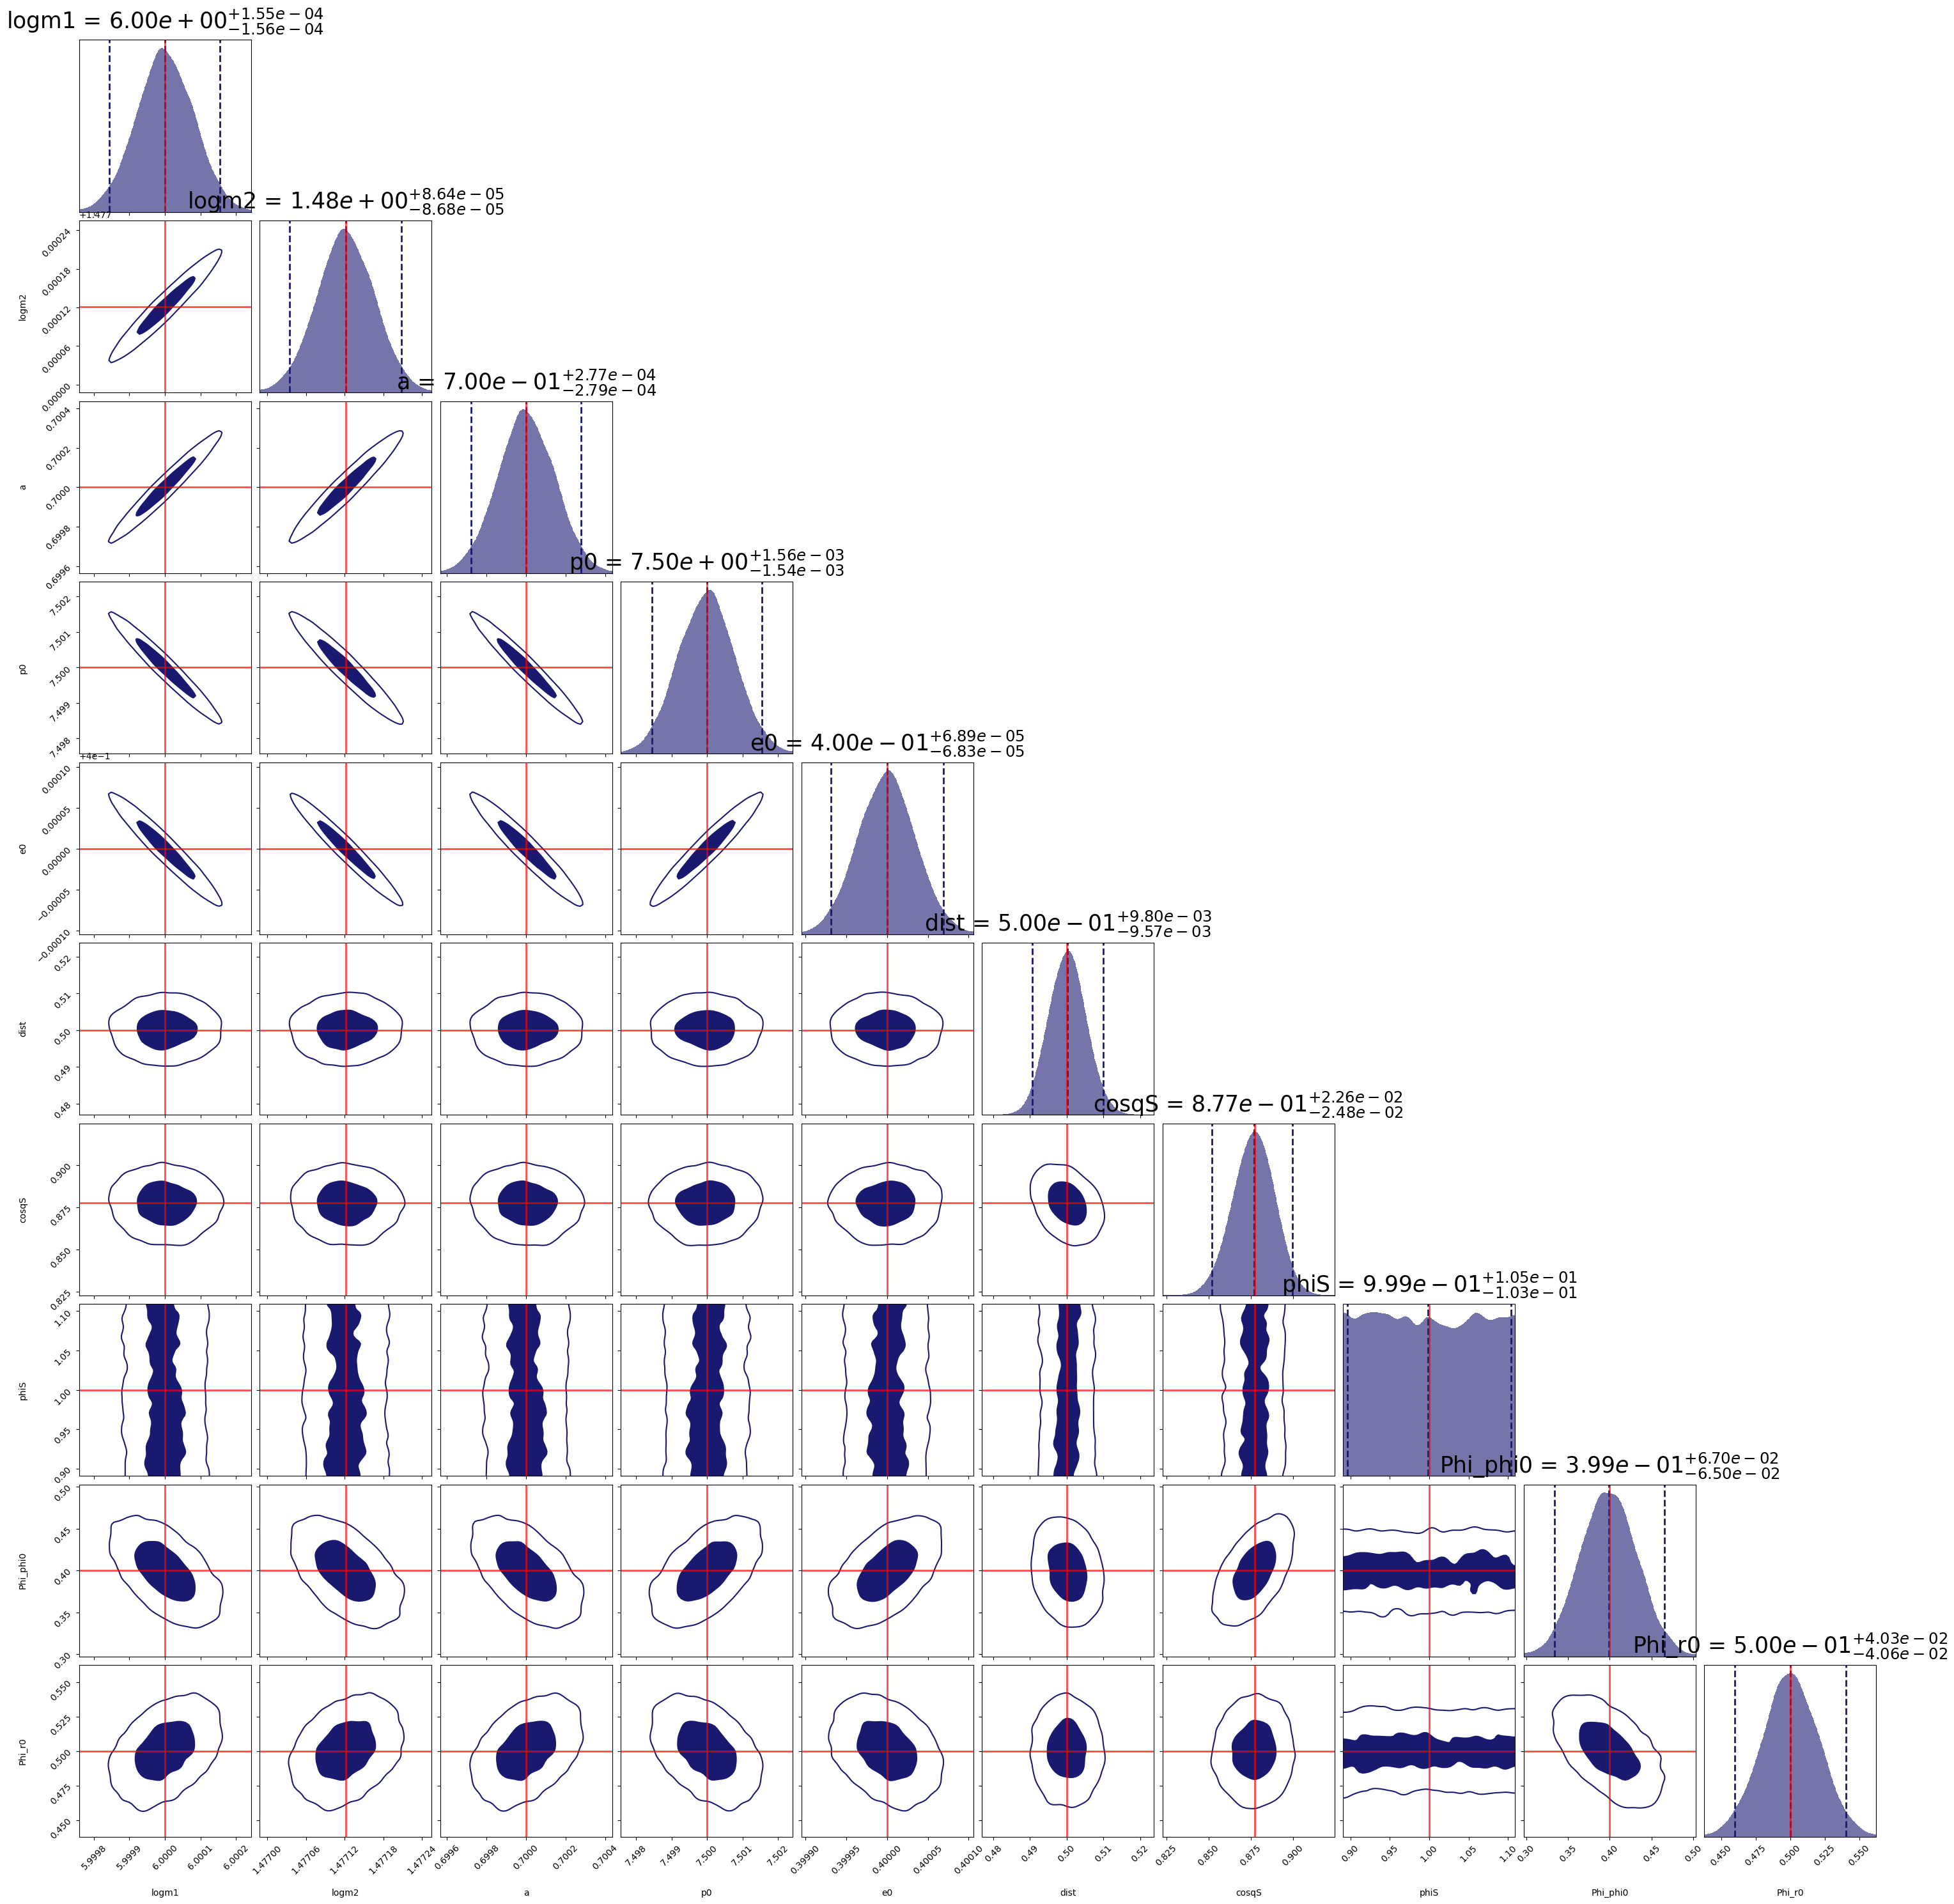

In [17]:
#cornerplot
from dynesty import plotting as dyplot
import matplotlib.pyplot as plt
fig, axes = dyplot.cornerplot(dres, show_titles=True, truth_color='red', smooth=0.03, color='midnightblue', quantiles_2d = [0.4, 0.85],
                              title_kwargs={'y': 1.04,'fontsize':25}, title_fmt='.2e',
                              fig=plt.subplots(ndim, ndim, figsize=(30, 30)), labels=labels, 
                              truths= param_true)


In [18]:

with open('ns_likelihoodtest_wide.pkl', 'rb') as f:
    dres = pickle.load(f)

with open('cov_matrix_new.pkl', 'rb') as f:
    cov_mat = pickle.load(f)


dynesty_samples = dres.samples
dynesty_weights = dres.importance_weights()

In [19]:
from scipy.stats import multivariate_normal

n_fisher_samples = 10000
fisher_samples = multivariate_normal.rvs(
    mean=param_true, 
    cov=cov_mat,     
    size=n_fisher_samples
)

In [20]:
param_ranges = [
    (5.999755966003094, 6.000244033996906),      # logm1
    (1.4769870513061485, 1.4772554581331763),    # logm2
    (0.6995637359288023, 0.7004362640711976),    # a
    (7.497572969128289, 7.502427030871711),      # p0
    (0.39989407441630453, 0.4001059255836955),   # e0
    (0.4671238045922167, 0.5328761954077833),    # dist
    (0.8175373164938913, 0.9376278072868542),    # cosqS
    (0.8907980491383655, 1.1092019508616344),    # phiS
    (0.2971011746225549, 0.5028988253774451),    # Phiphi
    (0.4374942669461721, 0.5625057330538279)     # Phir
]

In [22]:
import corner

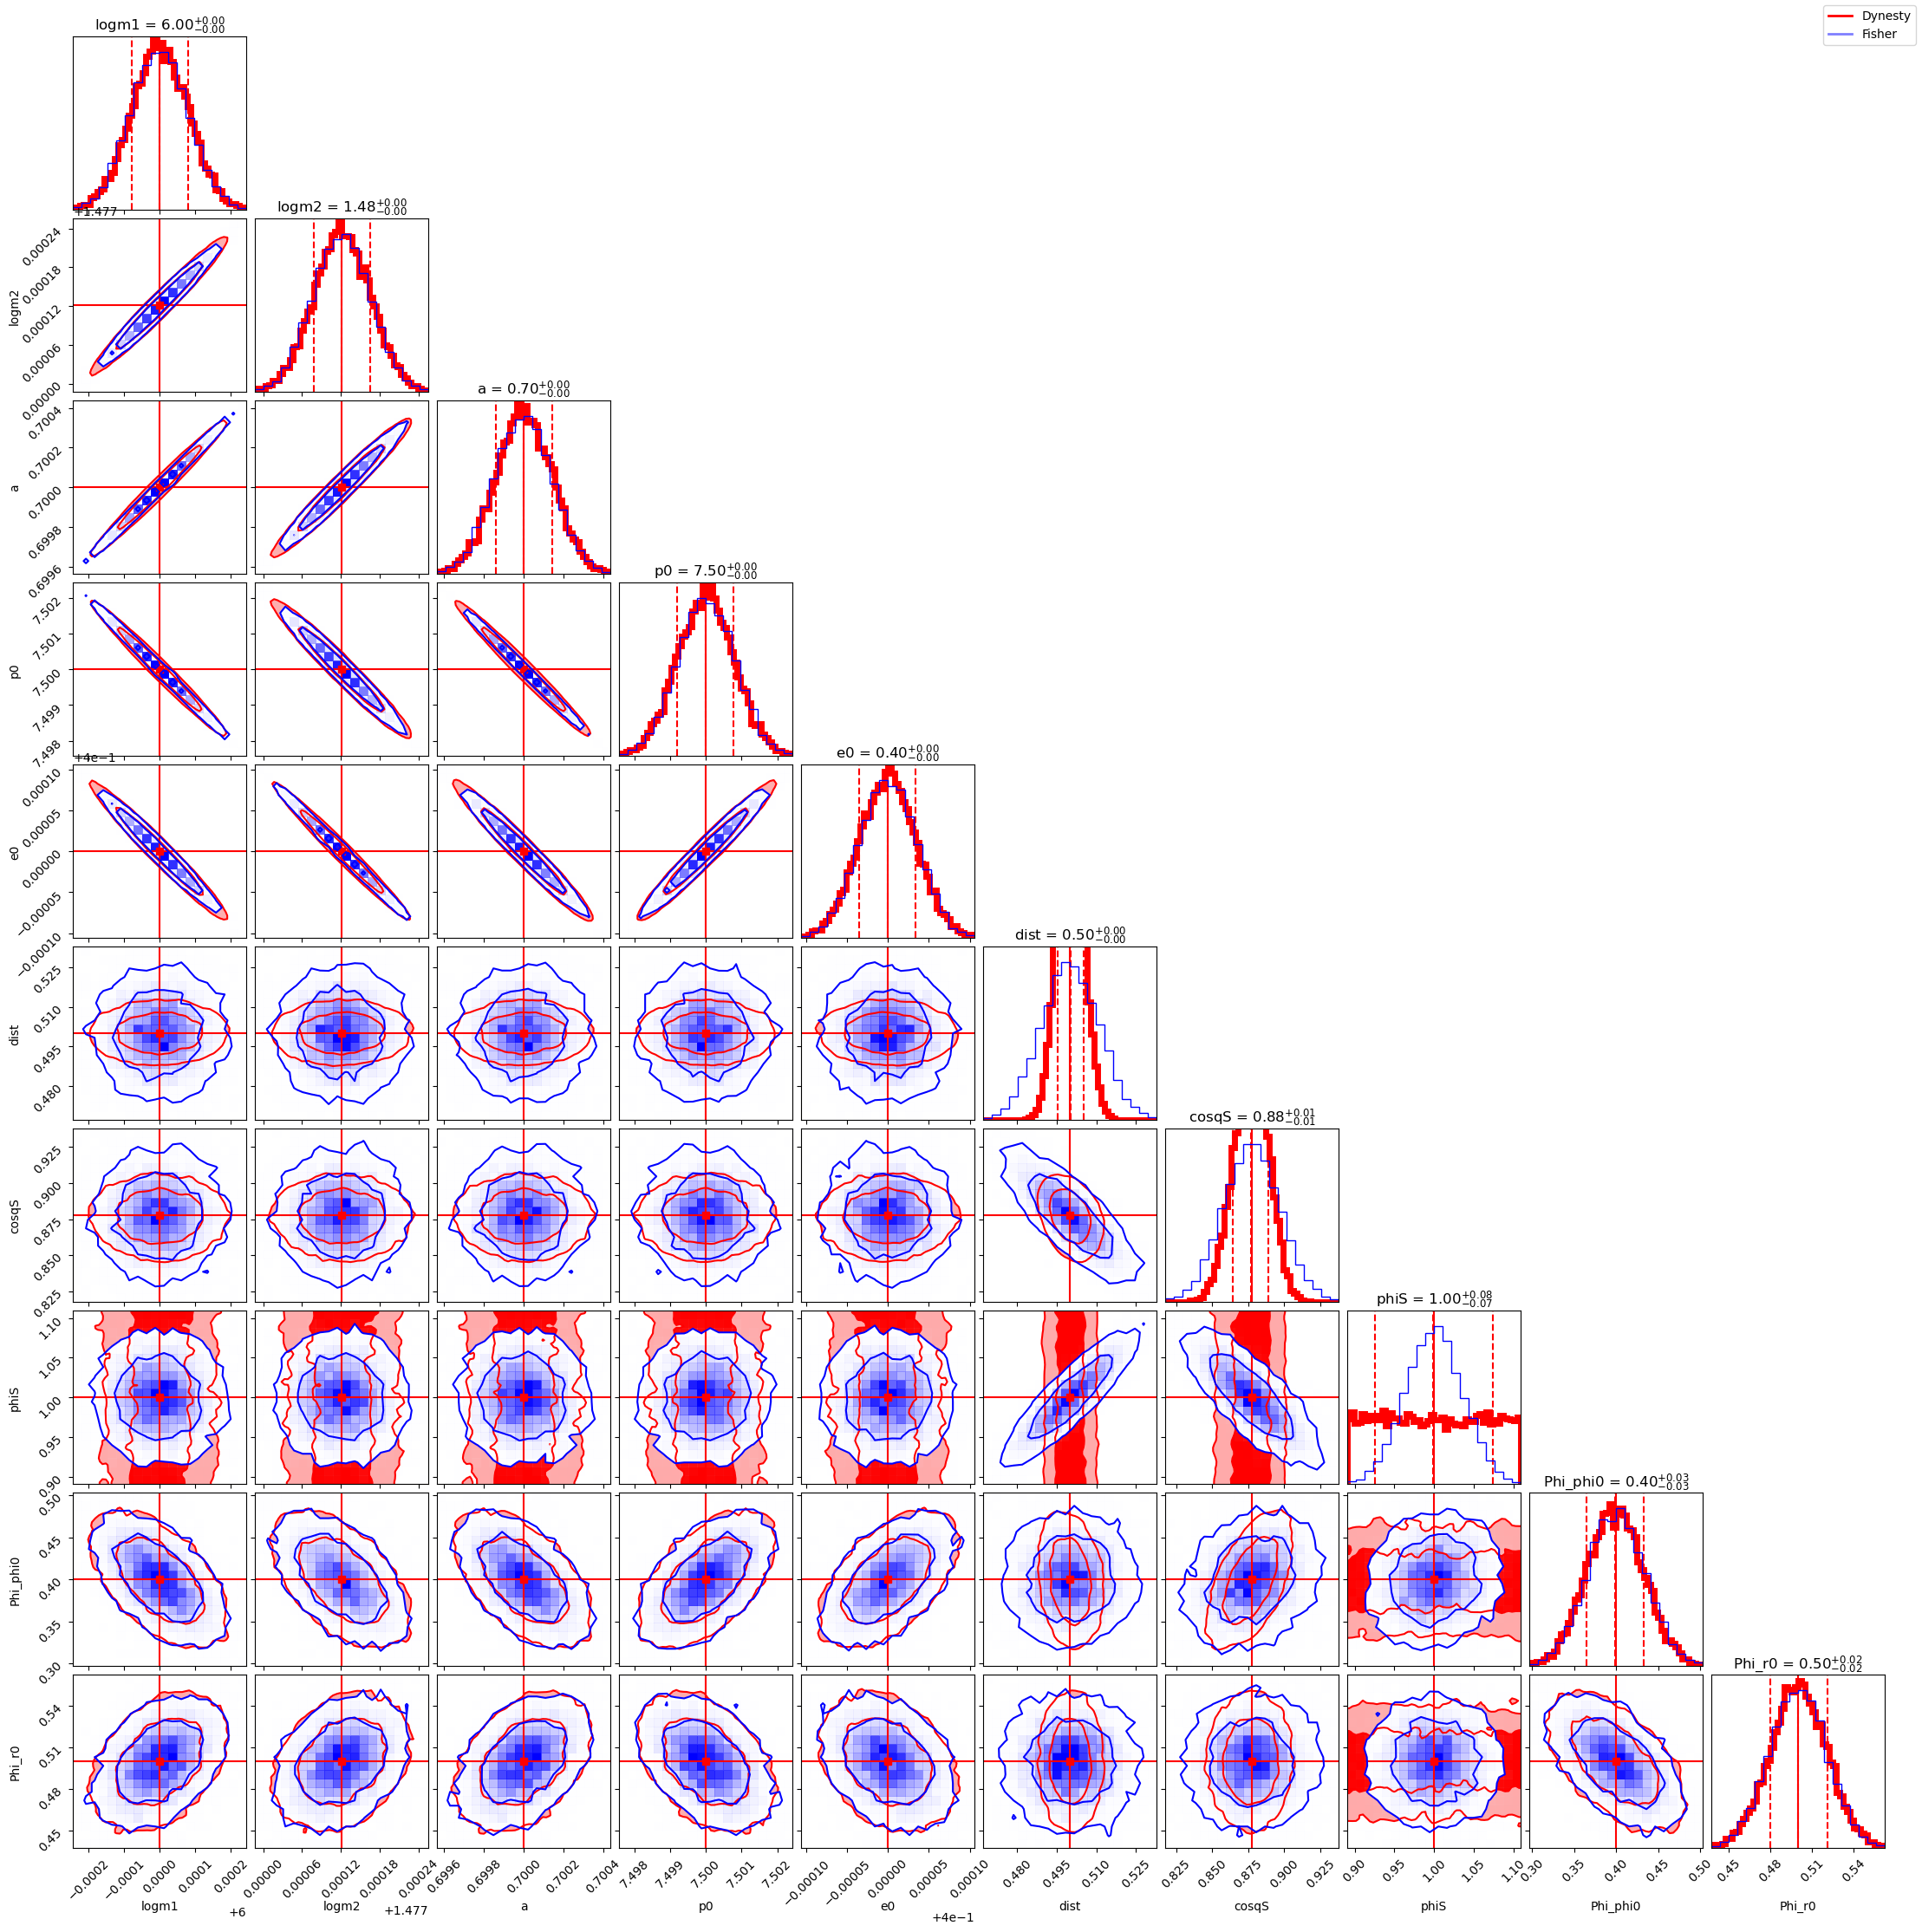

In [23]:
fig = corner.corner(
    dynesty_samples,
    weights=dynesty_weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    plot_density= True,
    levels=[0.68, 0.95],
    hist_kwargs={"density": True, 'linewidth': 5},
    linewidth=5,
    fill_contours=True,
    range = param_ranges
)

# Overlay Fisher ellipses
corner.corner(
    fisher_samples,
    fig=fig,
    color='blue',
    plot_datapoints=False,
    plot_density=True,
    levels=[0.68, 0.95],
    alpha=0.5,
    hist_kwargs={"density": True},
    range = param_ranges
)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    # Line2D([0], [0], color='green', lw=2, label='PARIS'),
    Line2D([0], [0], color='red', lw=2, label='Dynesty'),
    Line2D([0], [0], color='blue', lw=2, label='Fisher', alpha=0.5)
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)